In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

In [2]:
qSales = pd.read_csv('qSales_2024.csv')

display(qSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [3]:
qSales['tic'].unique()

array(['AAPL', 'TGT', 'NTDOY'], dtype=object)

In [5]:
#to get Target
target_sales = qSales.loc[qSales['tic']=='TGT']

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92],
 [Text(0, 0, '2001-01-31'),
  Text(1, 0, '2001-04-30'),
  Text(2, 0, '2001-07-31'),
  Text(3, 0, '2001-10-31'),
  Text(4, 0, '2002-01-31'),
  Text(5, 0, '2002-04-30'),
  Text(6, 0, '2002-07-31'),
  Text(7, 0, '2002-10-31'),
  Text(8, 0, '2003-01-31'),
  Text(9, 0, '2003-04-30'),
  Text(10, 0, '2003-07-31'),
  Text(11, 0, '2003-10-31'),
  Text(12, 0, '2004-01-31'),
  Text(13, 0, '2004-04-30'),
  Text(14, 0, '2004-07-31'),
  Text(15, 0, '2004-10-31'

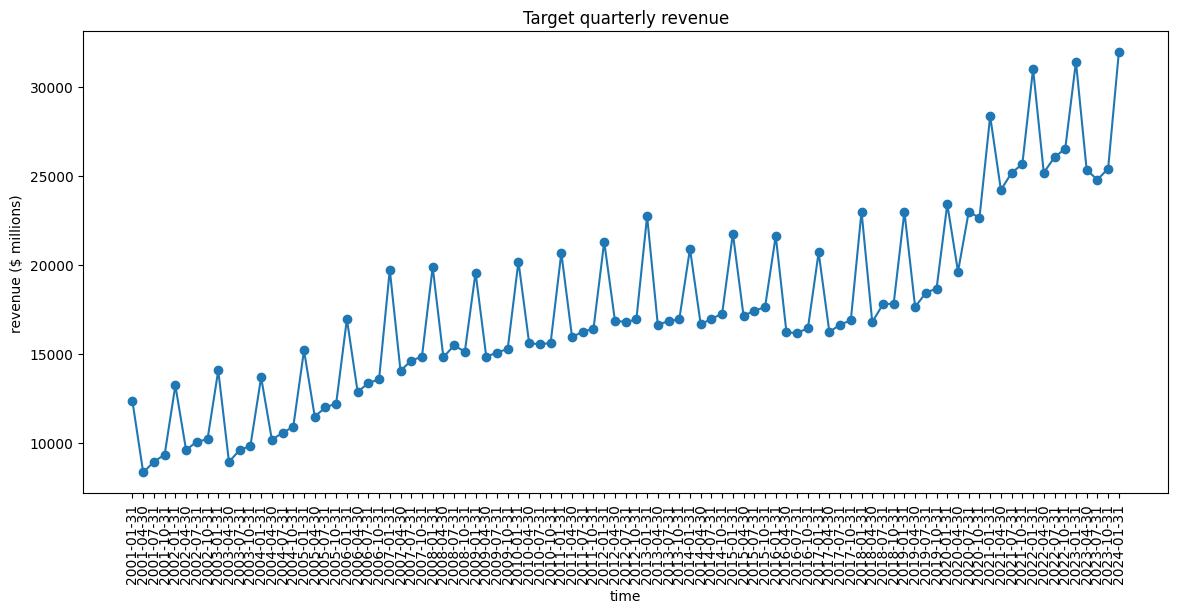

In [6]:
plt.figure(figsize=(14,6))

plt.title('Target quarterly revenue')

plt.xlabel('time')
plt.ylabel('revenue ($ millions)')

plt.plot(target_sales['datadate'],target_sales['saleq'],marker='o')

plt.xticks(rotation=90)

In [7]:
#average revenue by fiscal quarter to confirm the seasonal spike

target_sales.groupby('fqtr')['saleq'].mean()

,saleq
fqtr,
1,15868.43
2,16407.65
3,16608.22
4,21099.46


In [8]:
target_sales['time'] = range(1, len(target_sales)+1)

display(target_sales)

/tmp/ipykernel_995/380005918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['time'] = range(1, len(target_sales)+1)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92


In [9]:
#dummy variable 1 - the holiday quarter

target_sales['holiday_dv'] = np.where(target_sales['fqtr'] ==4, 1,0)

#dummy variable 2 - the post-2020 level shift
#everything from the quarter ending 2020-05-01 onwards gets a 1

target_sales['covid_dv'] = np.where(target_sales['datadate'] >= '2020-05-01', 1,0)

display(target_sales)

/tmp/ipykernel_995/1733956856.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['holiday_dv'] = np.where(target_sales['fqtr'] ==4, 1,0)
/tmp/ipykernel_995/1733956856.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['covid_dv'] = np.where(target_sales['datadate'] >= '2020-05-01', 1,0)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dv,covid_dv
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89,1,1
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90,0,1
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91,0,1
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92,0,1


In [10]:
#quick check that the dummies are switching on when we expect

target_sales.loc[:,['datadate','fqtr','time','saleq','holiday_dv','covid_dv']]

,datadate,fqtr,time,saleq,holiday_dv,covid_dv
92,2001-01-31,4,1,12324.00,1,0
93,2001-04-30,1,2,8334.00,0,0
94,2001-07-31,2,3,8941.00,0,0
95,2001-10-31,3,4,9331.00,0,0
96,2002-01-31,4,5,13220.00,1,0
...,...,...,...,...,...,...
180,2023-01-31,4,89,31395.00,1,1
181,2023-04-30,1,90,25322.00,0,1
182,2023-07-31,2,91,24773.00,0,1
183,2023-10-31,3,92,25398.00,0,1


In [11]:
x = target_sales.loc[:,['time','holiday_dv','covid_dv']]
x = sm.add_constant(x)

y = target_sales.loc[:,'saleq']

model_target = sm.OLS(y,x).fit()

model_target.params

,0
const,9497.38
time,129.18
holiday_dv,4771.70
covid_dv,4552.61


In [12]:
#the full output so we can see R-squared and the p values

model_target.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  saleq   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     602.9
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           5.44e-59
Time:                        17:42:44   Log-Likelihood:                -786.98
No. Observations:                  93   AIC:                             1582.
Df Residuals:                      89   BIC:                             1592.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9497.3806    276.676     34.327      0.000    8947.632       1e+04
time         129.1832      5.866     22.022      0.000     117.527     140.839
holiday_dv  4771.7003    277.409     17.201      0.000    4220.494    5322.907
covid_dv    4552.6145    428.173     10.633      0.000    3701.844    5403.385
==============================================================================
Omnibus:                       24.008   Durbin-Watson:                   0.302
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                5.218
Skew:                          -0.085   Prob(JB):                       0.0736
Kurtosis:                       1.852   Cond. No.                         200.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
#generate the fitted values from the model

target_sales['predicted'] = model_target.predict(x)

display(target_sales.loc[:,['datadate','saleq','predicted']])

/tmp/ipykernel_995/1204845052.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['predicted'] = model_target.predict(x)


,datadate,saleq,predicted
92,2001-01-31,12324.00,14398.26
93,2001-04-30,8334.00,9755.75
94,2001-07-31,8941.00,9884.93
95,2001-10-31,9331.00,10014.11
96,2002-01-31,13220.00,14915.00
...,...,...,...
180,2023-01-31,31395.00,30319.00
181,2023-04-30,25322.00,25676.48
182,2023-07-31,24773.00,25805.66
183,2023-10-31,25398.00,25934.85


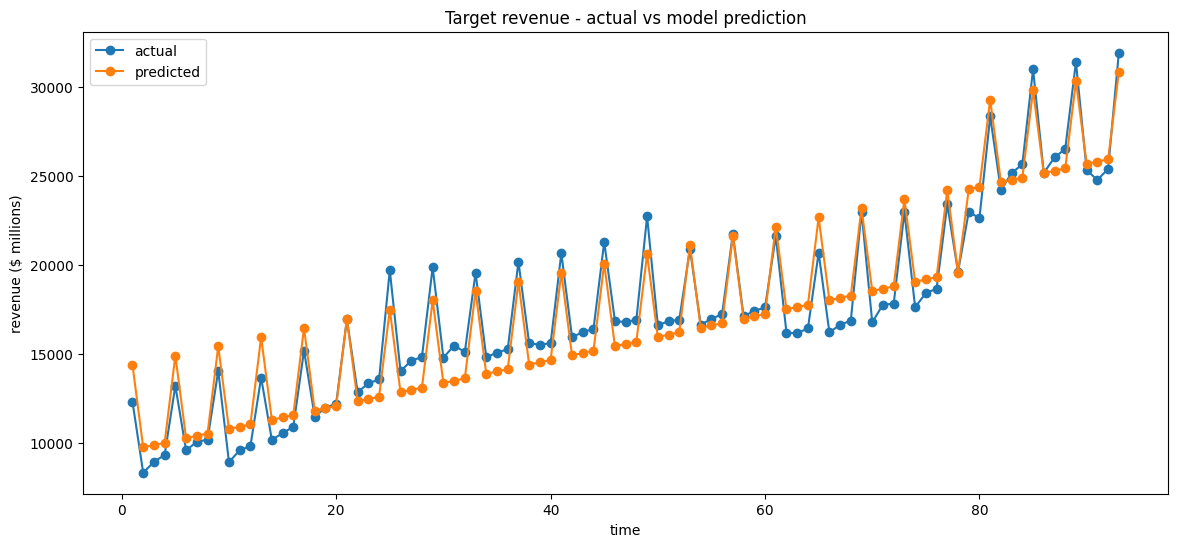

In [14]:
plt.figure(figsize=(14,6))

plt.title('Target revenue - actual vs model prediction')

plt.xlabel('time')
plt.ylabel('revenue ($ millions)')

plt.plot(target_sales['time'],target_sales['saleq'],marker='o',label='actual')
plt.plot(target_sales['time'],target_sales['predicted'],marker='o',label='predicted')

plt.legend()

In [15]:
prediction_results = model_target.get_prediction(x)
prediction_intervals = prediction_results.summary_frame(alpha=0.1) # confidence level of 90%

display(prediction_intervals)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
92,14398.26,332.35,13845.84,14950.68,12375.76,16420.77
93,9755.75,266.91,9312.11,10199.38,7760.21,11751.29
94,9884.93,262.08,9449.31,10320.55,7891.16,11878.70
95,10014.11,257.30,9586.44,10441.78,8022.06,12006.17
96,14915.00,316.98,14388.12,15441.87,12899.32,16930.68
...,...,...,...,...,...,...
180,30319.00,364.81,29712.62,30925.37,28281.09,32356.90
181,25676.48,312.00,25157.89,26195.06,23662.95,27690.01
182,25805.66,312.48,25286.27,26325.05,23791.92,27819.40
183,25934.85,313.08,25414.46,26455.23,23920.85,27948.84


#MEMO

**To:** Chapman Wealth Management
**From:** QuantFolio Solutions
**Re:** Target Corporation (TGT) - Quarterly Revenue Analysis
**Date:** July 2026


**WHAT THE 2 DUMMY VARIABLES CAPTURE ABOUT TARGET'S BUSINESS**

**Dummy 1 - holiday_dv**

This variable equals 1 in fiscal Q4 and 0 in all other quarters. Target's fiscal year ends in January, so its fourth fiscal quarter covers November, December and January - the Christmas shopping season. The coefficient of +4,772 million says the holiday quarter delivers roughly 4.8 billion dollars more revenue than a typical quarter, holding the trend constant. This is not noise: it recurs in all 24 holiday quarters in the sample. Fiscal Q4 averages 21.1 billion dollars against 15.9 to 16.6 billion for Q1 through Q3. This tells us Target is a general-merchandise retailer whose economics are concentrated in the gift-giving season.

**Dummy 2 - covid_dv**

This variable equals 1 from the quarter ending May 2020 onward and 0 before that. The coefficient of +4,553 million says that since the pandemic, Target's revenue in every quarter sits about 4.6 billion dollars above what the pre-2020 trend line alone would have predicted. This is a permanent step up in the level of the business, not a temporary bump - the series never returns to the old trend. Target was classified as an essential retailer, gained market share while competitors closed, and invested heavily in same-day fulfillment during that period. The data suggests those customers largely stayed.


**HOW WELL THE MODEL EXPLAINS TARGET'S REVENUE PATTERNS**

The fitted model is:

revenue = 9,497 + 129 (time) + 4,772 (holiday_dv) + 4,553 (covid_dv)

The R-squared is 0.953, meaning the three variables together explain about 95 percent of the variation in Target's quarterly revenue over 23 years. For a revenue series this is a strong fit. All three independent variables are statistically significant with p-values of 0.000.

The underlying trend is 129 million dollars per quarter, or about 517 million dollars of added revenue per year. This is steady but unspectacular organic growth. The actual-versus-predicted chart shows the model captures both the repeating seasonal spike and the 2020 structural break.

One caveat should be noted. The model assumes a constant linear growth rate across the full 23 years, and the residuals show some autocorrelation, with a Durbin-Watson statistic of 0.30. The model is well suited to describing the shape of the business and to near-term forecasting, but we would not extrapolate it far into the future without re-estimating on more recent data.


**KEY INSIGHTS FOR THE INVESTMENT DECISION**

1. Revenue is highly predictable. A three-variable model explains 95 percent of 23 years of quarterly revenue. From a risk standpoint, Target's top line carries little surprise. This is a stable, forecastable business rather than a volatile one.

2. Growth is real but modest. Roughly 517 million dollars per year of trend growth, on a base that now runs 25 to 30 billion dollars per quarter, is low-single-digit organic growth. Chapman should underwrite this as a steady compounder, not a growth story.

3. The Q4 concentration is the main operational risk. With approximately 4.8 billion dollars of incremental revenue riding on one quarter, a weak holiday season, an inventory misjudgment, or a consumer-spending shock in November or December has an outsized effect on the full year. Quarterly results should be compared to the same quarter of the prior year, never to the immediately preceding quarter.

4. The 2020 gain has held. The step up was a genuine, sustained expansion of the revenue base rather than a one-off spike. This is a positive signal about customer retention and about the durability of the fulfillment investments Target made.

5. The model has practical use going forward. The regression provides a baseline expectation for any future quarter. If a reported quarter lands materially outside the 90 percent prediction interval, that signals a genuine change in the business - a competitive shift, a margin problem, or a demand inflection - and warrants further review rather than being dismissed as seasonal variation.